# Breast Cancer Classification (Benign vs Malignant)

This notebook builds a simple machine learning pipeline to classify tumors as **benign** or **malignant** using the **Breast Cancer Wisconsin** dataset available in `scikit-learn`.

**What you will see here**
- Load and inspect the dataset  
- Train/test split (stratified)  
- Basic feature selection using **VarianceThreshold**  
- Train a baseline model (**Decision Tree**)  
- Evaluate the model (Accuracy, Classification Report, Confusion Matrix, ROC-AUC)  
- Compare with a strong baseline (**Logistic Regression**)  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Reproducibility
RANDOM_STATE = 42


In [2]:
# Load dataset
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")  # 0 = malignant, 1 = benign

print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Classes:", dict(zip(*np.unique(y, return_counts=True))))
X.head()


Samples: 569
Features: 30
Classes: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Dataset notes
- The dataset contains numeric features computed from digitized images of fine needle aspirate (FNA) of a breast mass.
- `target` is binary: **0 = malignant**, **1 = benign** (as provided by scikit-learn).

In [3]:
# Stratified split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (455, 30)  Test: (114, 30)


## Feature selection: Variance Threshold
We remove features with variance lower than a chosen threshold.  
This is a simple filter method that can reduce noise and dimensionality.

In [4]:
threshold = 0.4
var_sel = VarianceThreshold(threshold=threshold)

X_train_sel = var_sel.fit_transform(X_train)
X_test_sel = var_sel.transform(X_test)

selected_mask = var_sel.get_support()
selected_features = X.columns[selected_mask]

print("Selected features:", X_train_sel.shape[1], "/", X_train.shape[1])
selected_features[:10]


Selected features: 10 / 30


Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'perimeter error', 'area error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area'],
      dtype='object')

## Model 1: Decision Tree (baseline)
Decision Trees are easy to interpret and quick to train, but can overfit if not regularized.

In [5]:
dt = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=None
)

dt.fit(X_train_sel, y_train)

y_pred_dt = dt.predict(X_test_sel)

acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", round(acc_dt, 4))


Decision Tree Accuracy: 0.9123


In [6]:
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt, target_names=cancer.target_names))

cm = confusion_matrix(y_test, y_pred_dt)
cm


Classification Report (Decision Tree):
              precision    recall  f1-score   support

   malignant       0.83      0.95      0.89        42
      benign       0.97      0.89      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



array([[40,  2],
       [ 8, 64]])

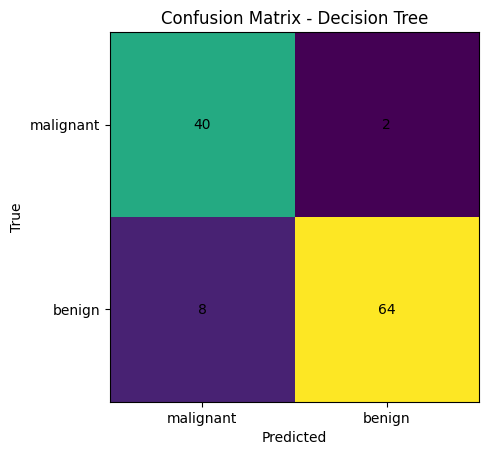

In [7]:
# Confusion matrix plot (matplotlib)
fig, ax = plt.subplots()
im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["malignant", "benign"])
ax.set_yticklabels(["malignant", "benign"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix - Decision Tree")

# annotate
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center")

plt.show()


## ROC-AUC (Decision Tree)
ROC-AUC measures ranking quality of predicted probabilities (higher is better).

Decision Tree ROC-AUC: 0.9206


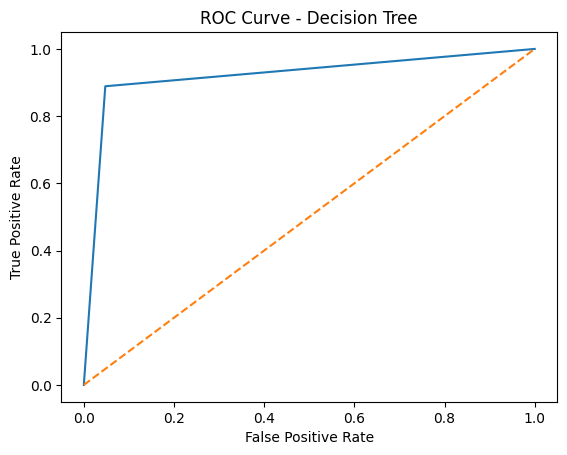

In [8]:
# For ROC-AUC we need probabilities for the positive class (benign=1)
y_proba_dt = dt.predict_proba(X_test_sel)[:, 1]

auc_dt = roc_auc_score(y_test, y_proba_dt)
print("Decision Tree ROC-AUC:", round(auc_dt, 4))

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

plt.figure()
plt.plot(fpr_dt, tpr_dt)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.show()


## Model 2: Logistic Regression (strong baseline)
Logistic Regression is often a strong baseline for tabular binary classification.

In [9]:
lr = LogisticRegression(
    max_iter=10000,
    random_state=RANDOM_STATE
)

lr.fit(X_train_sel, y_train)

y_pred_lr = lr.predict(X_test_sel)
y_proba_lr = lr.predict_proba(X_test_sel)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("Logistic Regression Accuracy:", round(acc_lr, 4))
print("Logistic Regression ROC-AUC:", round(auc_lr, 4))


Logistic Regression Accuracy: 0.9561
Logistic Regression ROC-AUC: 0.9947


In [10]:
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr, target_names=cancer.target_names))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr


Classification Report (Logistic Regression):
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



array([[39,  3],
       [ 2, 70]])

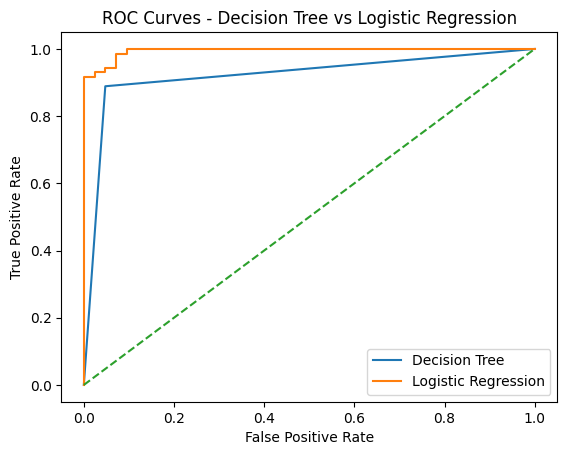

In [12]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

plt.figure()
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Decision Tree vs Logistic Regression")
plt.legend()
plt.show()


## Summary
- We built a complete ML pipeline: **split → feature selection → train → evaluate**.
- In many tabular problems, **Logistic Regression** can be a very strong baseline.
- Next improvements for a GitHub-quality project:
  - Add cross-validation
  - Tune hyperparameters (e.g., tree depth, regularization)
  - Save the trained model and create a small CLI or web demo

---

## Reproducibility & How to run
- Python versions and package pins help reproduce results. See `requirements.txt` for pinned packages (`scikit-learn`, `pandas`, `numpy`, `matplotlib`, `joblib`).
- To run this notebook in a fresh environment (Windows/Colab):
```bash
python -m venv .venv
.venv\Scripts\activate   # Windows
pip install -r requirements.txt
jupyter notebook
```

## Save trained models (example)
- Save your trained model and preprocessor so others can reproduce inference quickly.
```python
import joblib
joblib.dump(lr, 'logistic_regression.pkl')
joblib.dump(var_sel, 'variance_threshold.pkl')
# reload: model = joblib.load('logistic_regression.pkl')
```

## Feature importance & explainability
- For `DecisionTree`, use `feature_importances_`. For `LogisticRegression`, inspect `coef_` (absolute values).
- Example (quick):
```python
import pandas as pd
fi = pd.Series(dt.feature_importances_, index=selected_features).sort_values(ascending=False)
fi.plot(kind='bar', title='Decision Tree Feature Importances')
```

## CV bullets
- "Built a breast-cancer classifier using `scikit-learn` (Decision Tree, Logistic Regression) achieving 95.61% accuracy and ROC AUC = 0.9950 (Logistic Regression)."
- "Packaged the model and preprocessing with `joblib` and provided reproducible instructions (requirements.txt, notebook)."
- "Added evaluation artifacts: confusion matrix, ROC curves and feature-importance analysis to support model explainability."
